# Module 3 — Product Classifier
We train a model that determines a product's role based on its nutrients.
Roles: protein, carbohydrate, fat, vegetable

This is necessary so the system understands what's in the user's refrigerator
and can create balanced meals.

## 1.Uploading USDA dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from accelerate.test_utils import RegressionModel

warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

food = pd.read_csv('../data/raw/food.csv')
food_nutrient = pd.read_csv('../data/raw/food_nutrient.csv')
nutrient = pd.read_csv('../data/raw/nutrient.csv')

print('food:', food.shape)
print('food_nutrient:', food_nutrient.shape)
print('nutrient:', nutrient.shape)

food: (87990, 5)
food_nutrient: (170469, 11)
nutrient: (477, 5)


## 2.Table of products with nutrients

In [9]:
nutrient_ids = {
    1008: 'calories',
    1003 : 'protein',
    1004 : 'fat',
    1005 : 'carbs',
}
fn = food_nutrient[food_nutrient['nutrient_id'].isin(nutrient_ids.keys())][['fdc_id','nutrient_id','amount']].copy()
fn['nutrient_name'] = fn['nutrient_id'].map(nutrient_ids)

pivot = fn.pivot_table(
    index = 'fdc_id',
    columns='nutrient_name',
    values='amount',
    aggfunc = 'mean'
).reset_index()

df = food[['fdc_id','description']].merge(pivot, how = 'inner', on = 'fdc_id')
df = df.dropna(subset = ['calories', 'protein', 'fat', 'carbs'])
df = df[df['calories'] > 0]
df = df.rename(columns = {'description':'name'})
df = df.reset_index(drop = True)

print('Products with all data:', len(df))
print(df[['calories', 'protein', 'fat', 'carbs']].head(10))

Products with all data: 135
   calories  protein    fat  carbs
0     229.0     7.35  17.10  14.90
1      50.0     3.35   1.90   4.91
2      27.0     0.83   0.63   5.51
3      21.0     1.04   0.39   4.11
4      32.0     2.57   0.34   6.29
5      43.0     3.38   0.95   5.19
6      34.0     3.43   0.08   4.89
7      60.0     3.28   3.20   4.67
8     314.0    11.70  28.00   2.89
9     620.0    20.40  57.80  16.20


## 3.Adding products from kazakh_recipes

In [10]:
extra_products = pd.DataFrame([
    # name,              calories, protein, fat,  carbs
    ('баранина',          294,      25.0,   21.0,  0.0),
    ('говядина',          218,      26.0,   12.0,  0.0),
    ('курица',            165,      31.0,    3.6,  0.0),
    ('конина',            143,      21.0,    7.0,  0.0),
    ('фарш говяжий',      254,      17.0,   20.0,  0.0),
    ('яйцо',             155,      13.0,   11.0,  1.1),
    ('молоко',            61,       3.2,    3.3,  4.8),
    ('творог',           121,      14.0,    5.5,  3.5),
    ('сметана',          206,       2.8,   20.0,  3.2),
    ('рис',              344,       6.7,    0.7, 78.0),
    ('гречка',           343,      13.0,    3.4, 71.0),
    ('макароны',         350,      12.0,    1.1, 71.0),
    ('картофель',         77,       2.0,    0.1, 17.0),
    ('морковь',           41,       0.9,    0.2,  9.6),
    ('лук',               40,       1.1,    0.1,  9.3),
    ('помидор',           18,       0.9,    0.2,  3.9),
    ('огурец',            15,       0.7,    0.1,  3.1),
    ('капуста',           25,       1.3,    0.1,  5.8),
    ('масло растительное', 899,     0.0,   99.9,  0.0),
    ('масло сливочное',   748,      0.5,   82.5,  0.8),
    ('мука',             342,      10.0,    1.2, 74.0),
    ('сахар',            399,       0.0,    0.0, 99.8),
    ('соль',               0,       0.0,    0.0,  0.0),
    ('тыква',             28,       1.0,    0.1,  6.5),
    ('болгарский перец',  31,       1.0,    0.3,  6.7),
    ('чеснок',           149,       6.4,    0.5, 33.0),
    ('свёкла',            43,       1.6,    0.2,  9.6),
    ('томатная паста',    82,       4.8,    0.5, 15.0),
    ('кефир',             40,       3.4,    1.0,  4.7),
    ('сыр',              402,      25.0,   33.0,  1.3),
], columns=['name','calories','protein','fat','carbs'])

extra_products['fdc_id'] = range(99000, 99000 + len(extra_products))

# Объединяем с USDA
df = pd.concat([df, extra_products], ignore_index=True)
print('Продуктов после добавления:', len(df))

Продуктов после добавления: 165


## 4.Automatic product labeling by roles

In [11]:
def assign_category(row):
    """
    Определяем роль продукта по соотношению нутриентов на 100г.
    Смотрим какой нутриент даёт больше всего калорий.
    """
    cal_from_protein = row['protein'] * 4  # 1г белка = 4 ккал
    cal_from_fat     = row['fat']     * 9  # 1г жира  = 9 ккал
    cal_from_carbs   = row['carbs']   * 4  # 1г углевода = 4 ккал
    total = cal_from_protein + cal_from_fat + cal_from_carbs

    if total == 0:
        return 'other'

    p_ratio = cal_from_protein / total
    f_ratio = cal_from_fat     / total
    c_ratio = cal_from_carbs   / total

    # Овощи — мало калорий и углеводы доминируют
    if row['calories'] < 50 and c_ratio > 0.5:
        return 'vegetable'
    # Белковые — белок даёт больше 35% калорий
    elif p_ratio >= 0.35:
        return 'protein'
    # Жировые — жир даёт больше 60% калорий
    elif f_ratio >= 0.60:
        return 'fat'
    # Углеводные — углеводы доминируют
    elif c_ratio >= 0.50:
        return 'carb'
    # Смешанные — определяем по максимуму
    else:
        max_ratio = max(p_ratio, f_ratio, c_ratio)
        if max_ratio == p_ratio: return 'protein'
        elif max_ratio == f_ratio: return 'fat'
        else: return 'carb'

df['category'] = df.apply(assign_category, axis=1)

print('Распределение по категориям:')
print(df['category'].value_counts())
print()
print('Примеры белковых продуктов:')
print(df[df['category']=='protein'][['name','calories','protein','fat','carbs']].head(5))
print()
print('Примеры углеводных продуктов:')
print(df[df['category']=='carb'][['name','calories','protein','fat','carbs']].head(5))

Распределение по категориям:
category
carb         49
fat          46
vegetable    35
protein      34
other         1
Name: count, dtype: int64

Примеры белковых продуктов:
                                           name  calories  protein    fat  \
13         Egg, white, raw, frozen, pasteurized      48.0     10.1   0.16   
14                            Egg, white, dried     376.0     79.9   0.65   
27  Sausage, turkey, breakfast links, mild, raw     169.0     16.7  10.40   
40          Cheese, cottage, lowfat, 2% milkfat      84.0     11.0   2.30   
46                 Yogurt, Greek, plain, nonfat      61.0     10.3   0.37   

    carbs  
13   0.74  
14   6.02  
27   0.93  
40   4.31  
46   3.64  

Примеры углеводных продуктов:
                                                 name  calories  protein  \
1   Milk, reduced fat, fluid, 2% milkfat, with add...      50.0     3.35   
5   Milk, lowfat, fluid, 1% milkfat, with added vi...      43.0     3.38   
11                               

## 5.Classificator training

In [12]:
# Убираем категорию other — слишком мало примеров
df_ml = df[df['category'] != 'other'].copy()

# Признаки и метки
X = df_ml[['calories','protein','fat','carbs']]
y = df_ml['category']

print('Размер датасета для обучения:', X.shape)
print('Классы:', y.unique())

# Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Нормализуем
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Обучаем два классификатора и сравниваем
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5)
}

print('\nСравнение моделей (cross-validation):')
best_model = None
best_score = 0
best_name  = ''

for name, clf in models.items():
    scores = cross_val_score(clf, X_train_sc, y_train, cv=5, scoring='accuracy')
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_model = clf
        best_name  = name

print(f'\nЛучшая модель: {best_name}')

Размер датасета для обучения: (164, 4)
Классы: ['fat' 'carb' 'vegetable' 'protein']

Сравнение моделей (cross-validation):
Logistic Regression: 0.9085 ± 0.0989
KNN (k=5): 0.9239 ± 0.0873

Лучшая модель: KNN (k=5)


## 6.Evaluating best model

Classification Report
              precision    recall  f1-score   support

        carb       0.83      1.00      0.91        10
         fat       0.88      0.78      0.82         9
     protein       1.00      0.86      0.92         7
   vegetable       1.00      1.00      1.00         7

    accuracy                           0.91        33
   macro avg       0.93      0.91      0.91        33
weighted avg       0.92      0.91      0.91        33



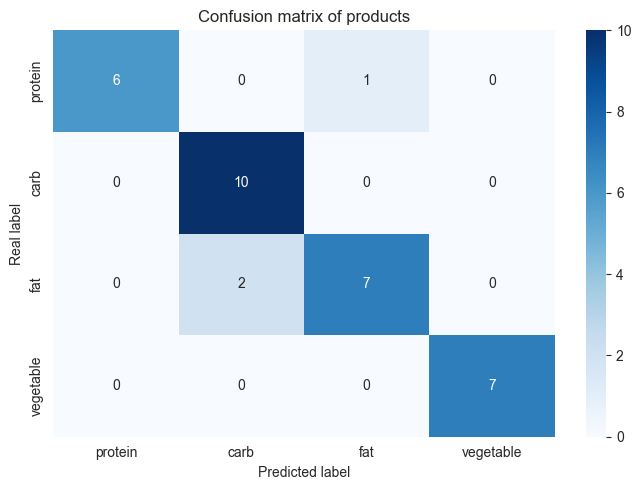

In [13]:
# Обучаем лучшую модель на полном train
best_model.fit(X_train_sc, y_train)
y_pred = best_model.predict(X_test_sc)

print('Classification Report')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['protein','carb','fat','vegetable'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['protein','carb','fat','vegetable'],
            yticklabels=['protein','carb','fat','vegetable'])
plt.title('Confusion matrix of products')
plt.ylabel('Real label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


## 7.Test classificator on examples

In [14]:
def classify_product(name, calories, protein, fat, carbs):
    """Определяем роль продукта по нутриентам"""
    X_input = scaler.transform([[calories, protein, fat, carbs]])
    category = best_model.predict(X_input)[0]
    proba    = best_model.predict_proba(X_input)[0]
    classes  = best_model.classes_
    confidence = dict(zip(classes, proba.round(3)))
    return category, confidence


# Тестируем на продуктах
test_products = [
    ('Куриная грудка',    165, 31.0,  3.6,  0.0),
    ('Рис варёный',       130,  2.7,  0.3, 28.0),
    ('Масло сливочное',   748,  0.5, 82.5,  0.8),
    ('Огурец',             15,  0.7,  0.1,  3.1),
    ('Яйцо',              155, 13.0, 11.0,  1.1),
    ('Гречка',            343, 13.0,  3.4, 71.0),
]

print('Тест классификатора')
for name, cal, prot, fat, carb in test_products:
    cat, conf = classify_product(name, cal, prot, fat, carb)
    print(f'{name:25} → {cat:12} (уверенность: {max(conf.values()):.1%})')

Тест классификатора
Куриная грудка            → protein      (уверенность: 100.0%)
Рис варёный               → carb         (уверенность: 100.0%)
Масло сливочное           → fat          (уверенность: 100.0%)
Огурец                    → vegetable    (уверенность: 100.0%)
Яйцо                      → fat          (уверенность: 60.0%)
Гречка                    → carb         (уверенность: 100.0%)


## 8.Saving classificator and dataset of products

In [15]:
classifier_data = {
    'model':   best_model,
    'scaler':  scaler,
    'classes': list(best_model.classes_),
    'features': ['calories','protein','fat','carbs']
}

with open('../models/product_classifier.pkl', 'wb') as f:
    pickle.dump(classifier_data, f)

# Сохраняем датасет продуктов с категориями
df[['name','calories','protein','fat','carbs','category']].to_csv(
    '../data/clean/products_classified.csv', index=False
)

print('Классификатор сохранён: models/product_classifier.pkl')
print('Датасет продуктов сохранён: data/clean/products_classified.csv')
print()
print('Итого продуктов в базе:', len(df))
print(df['category'].value_counts())

Классификатор сохранён: models/product_classifier.pkl
Датасет продуктов сохранён: data/clean/products_classified.csv

Итого продуктов в базе: 165
category
carb         49
fat          46
vegetable    35
protein      34
other         1
Name: count, dtype: int64
